# Newton Method and Standard BFGS

This notebook is designed for teaching.

The goal of this notebook is to program the following methods:

We include:
- Newton's method,
- Newton's method with Armijo backtracking,
- standard BFGS,
- a comparison with standard library implementations.

For each method, we show:
- the final solution,
- the evolution of the loss function,
- the number of iterations used.

In all methods, the maximum number of iterations is both:
- an input of the algorithm,
- and a stopping criterion.


## Imports

We use:
- `numpy` for vector and matrix computations,
- `matplotlib` for plotting the loss history.


In [32]:
# Import NumPy for vector and matrix computations.
import numpy as np

# Import matplotlib for plotting the loss history.
import matplotlib.pyplot as plt

# Import the time module to measure execution time.
import time

# Import pandas to build summary tables.
import pandas as pd

## Generic implementations

The implementations below are written only once.

Each optimization algorithm receives as input the objective function, its gradient, and the Hessian when necessary.
This allows us to use the same code in all experiments.


### Newton's method

Newton's method computes the direction $p_k$ by solving
\begin{equation}
H_f(x_k)p_k=-\nabla f(x_k),
\end{equation}
and then updates
\begin{equation}
x_{k+1}=x_k+\alpha_k p_k.
\end{equation}

In the pure Newton method below, we use
\begin{equation}
\alpha_k=1.
\end{equation}


In [33]:
# Define the pure Newton method.
def newton_method(f, grad_f, hess_f, x0, tol=1e-8, max_iter=50):
    # Copy the initial point.
    x = x0.astype(float).copy()
    # Create a list to store the loss values.
    losses = []

    # Start the iteration loop.
    for k in range(max_iter):
        # Compute the current loss.
        loss = f(x)
        # Store the current loss.
        losses.append(loss)
        # Compute the current gradient.
        g = grad_f(x)

        # Check the stopping criterion based on the gradient norm.
        if np.linalg.norm(g) < tol:
            # Stop if the gradient is small enough.
            break

        # Compute the current Hessian matrix.
        H = hess_f(x)
        # Compute the direction (Solve the Newton linear system H p = -g.).
        p = np.linalg.solve(H, -g)
        # Update the iterate using alpha_k = 1.
        x = x + p

    # Return the final point, the loss history, and the number of iterations used.
    return x, losses, k + 1

### Newton's method with Armijo backtracking

To improve robustness, we can keep the Newton direction but choose the step size by backtracking.

The update is still
\begin{equation}
x_{k+1}=x_k+\alpha_k p_k,
\end{equation}
but now $\alpha_k$ is chosen so that the loss decreases sufficiently.

We use the Armijo condition:
\begin{equation}
f(x_k+\alpha_k p_k)\leq f(x_k)+c\,\alpha_k\,\nabla f(x_k)^T p_k.
\end{equation}


In [34]:
# Define Newton's method with Armijo backtracking.
def newton_armijo(f, grad_f, hess_f, x0, tol=1e-8, max_iter=50, alpha0=1.0, rho=0.5, c=1e-4):
    # Copy the initial point.
    x = x0.astype(float).copy()
    # Create a list to store the loss values.
    losses = []

    # Start the iteration loop.
    for k in range(max_iter):
        # Compute the current loss.
        loss = f(x)
        # Store the current loss.
        losses.append(loss)
        # Compute the current gradient.
        g = grad_f(x)

        # Check the stopping criterion based on the gradient norm.
        if np.linalg.norm(g) < tol:
            # Stop if the gradient is small enough.
            break

        # Compute the current Hessian matrix.
        H = hess_f(x)
        # Compute the direction (Solve the Newton linear system H p = -g.).
        p = np.linalg.solve(H, -g)
        # Initialize the step size.
        alpha = alpha0

        # Backtrack until the Armijo condition is satisfied.
        while f(x + alpha * p) > loss + c * alpha * np.dot(g, p):
            # Reduce the step size.
            alpha = rho * alpha

        # Update the iterate.
        x = x + alpha * p

    # Return the final point, the loss history, and the number of iterations used.
    return x, losses, k + 1

### Standard BFGS

BFGS is a quasi-Newton method.

Instead of using the exact Hessian, it builds an approximation $H_k$ of the inverse Hessian and uses the direction
\begin{equation}
p_k=-H_k \nabla f(x_k).
\end{equation}

Then it updates the inverse Hessian approximation using
\begin{equation}
s_k=x_{k+1}-x_k,
\qquad
y_k=\nabla f(x_{k+1})-\nabla f(x_k).
\end{equation}

We also use Armijo backtracking to choose the step size.


In [35]:
# Define the standard BFGS method.
def bfgs_method(f, grad_f, x0, tol=1e-8, max_iter=100, alpha0=1.0, rho=0.5, c=1e-4):
    # Copy the initial point.
    x = x0.astype(float).copy()
    # Compute the dimension of the problem.
    n = len(x)
    # Initialize the inverse Hessian approximation with the identity matrix.
    Hinv = np.eye(n)
    # Create a list to store the loss values.
    losses = []

    # Start the iteration loop.
    for k in range(max_iter):
        # Compute the current loss.
        loss = f(x)
        # Store the current loss.
        losses.append(loss)
        # Compute the current gradient.
        g = grad_f(x)

        # Check the stopping criterion based on the gradient norm.
        if np.linalg.norm(g) < tol:
            # Stop if the gradient is small enough.
            break

        # Compute the BFGS search direction.
        p = -Hinv @ g
        # Initialize the step size.
        alpha = alpha0

        # Backtrack until the Armijo condition is satisfied.
        while f(x + alpha * p) > loss + c * alpha * np.dot(g, p):
            # Reduce the step size.
            alpha = rho * alpha

        # Compute the new point.
        x_new = x + alpha * p
        # Compute the new gradient.
        g_new = grad_f(x_new)
        # Compute the step difference.
        s = x_new - x
        # Compute the gradient difference.
        y = g_new - g
        # Compute the curvature quantity.
        ys = np.dot(y, s)

        # Update the inverse Hessian approximation only if the curvature condition holds.
        if ys > 1e-12:
            # Compute the reciprocal curvature.
            r = 1.0 / ys
            # Create the identity matrix.
            I = np.eye(n)
            # Apply the BFGS inverse update.
            Hinv = (I - r * np.outer(s, y)) @ Hinv @ (I - r * np.outer(y, s)) + r * np.outer(s, s)

        # Accept the new point.
        x = x_new

    # Return the final point, the loss history, and the number of iterations used.
    return x, losses, k + 1

## Example 1

We use the following two-variable function:
\begin{equation}
f(x)=\frac{1}{2}(x_1-1)^2 + (x_2+2)^2 + 0.1(x_1-1)^4,
\qquad
x=
\begin{pmatrix}
x_1\\
x_2
\end{pmatrix}.
\end{equation}

Its gradient is
\begin{equation}
\nabla f(x)=
\begin{pmatrix}
(x_1-1)+0.4(x_1-1)^3\\
2(x_2+2)
\end{pmatrix},
\end{equation}
and its Hessian is
\begin{equation}
H_f(x)=
\begin{pmatrix}
1+1.2(x_1-1)^2 & 0\\
0 & 2
\end{pmatrix}.
\end{equation}

The minimizer is
\begin{equation}
x^\star=
\begin{pmatrix}
1\\
-2
\end{pmatrix}.
\end{equation}


In [36]:
# Define the objective function for Example 1.
def f_example_1(x):
    # Extract the first component.
    x1 = x[0]
    # Extract the second component.
    x2 = x[1]
    # Return the function value.
    return 0.5 * (x1 - 1.0)**2 + (x2 + 2.0)**2 + 0.1 * (x1 - 1.0)**4

# Define the gradient of the objective function for Example 1.
def grad_f_example_1(x):
    # Extract the first component.
    x1 = x[0]
    # Extract the second component.
    x2 = x[1]
    # Return the gradient vector.
    return np.array([
        (x1 - 1.0) + 0.4 * (x1 - 1.0)**3,
        2.0 * (x2 + 2.0)
    ])

# Define the Hessian matrix of the objective function for Example 1.
def hess_f_example_1(x):
    # Extract the first component.
    x1 = x[0]
    # Return the Hessian matrix.
    return np.array([
        [1.0 + 1.2 * (x1 - 1.0)**2, 0.0],
        [0.0, 2.0]
    ])

### Run the methods

We choose the same initial point for all methods and compare:
- final solution,
- number of iterations,
- loss evolution.


In [37]:
# Define the common initial point for Example 1.
x0_example_1 = np.array([4.0, 3.0])

# Run pure Newton's method on Example 1.
x_newton, losses_newton, it_newton = newton_method(
    f_example_1,
    grad_f_example_1,
    hess_f_example_1,
    x0_example_1,
    tol=1e-8,
    max_iter=50
)

# Run Newton's method with Armijo backtracking on Example 1.
x_newton_armijo, losses_newton_armijo, it_newton_armijo = newton_armijo(
    f_example_1,
    grad_f_example_1,
    hess_f_example_1,
    x0_example_1,
    tol=1e-8,
    max_iter=50
)

# Run standard BFGS on Example 1.
x_bfgs, losses_bfgs, it_bfgs = bfgs_method(
    f_example_1,
    grad_f_example_1,
    x0_example_1,
    tol=1e-8,
    max_iter=100
)

# Print the results for pure Newton.
print("Pure Newton")
print("solution        =", x_newton)
print("iterations      =", it_newton)
print("final loss      =", losses_newton[-1])
print()

# Print the results for Newton with Armijo.
print("Newton + Armijo")
print("solution        =", x_newton_armijo)
print("iterations      =", it_newton_armijo)
print("final loss      =", losses_newton_armijo[-1])
print()

# Print the results for BFGS.
print("BFGS")
print("solution        =", x_bfgs)
print("iterations      =", it_bfgs)
print("final loss      =", losses_bfgs[-1])

Pure Newton
solution        = [ 1. -2.]
iterations      = 7
final loss      = 2.2186712959340957e-29

Newton + Armijo
solution        = [ 1. -2.]
iterations      = 7
final loss      = 2.2186712959340957e-29

BFGS
solution        = [ 1. -2.]
iterations      = 13
final loss      = 6.901216964837306e-21


### Combined plot 


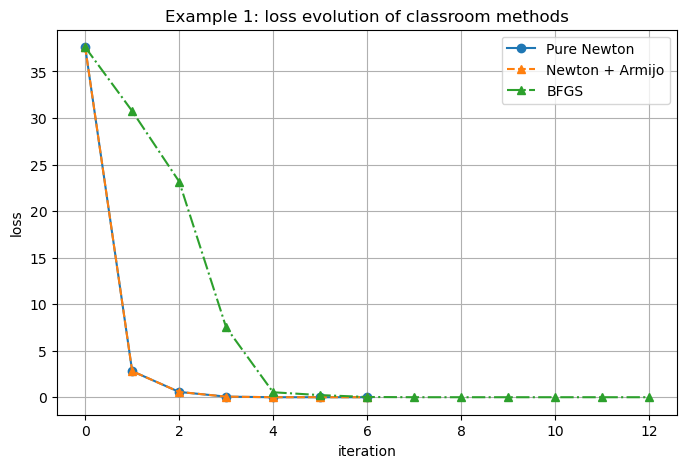

In [38]:
# Create a new figure.
plt.figure(figsize=(8, 5))

# Plot the loss history of pure Newton with a dashed line.
plt.plot(losses_newton, marker="o", label="Pure Newton")

# Plot the loss history of Newton with Armijo with a solid line.
plt.plot(losses_newton_armijo, marker="^", linestyle="--", label="Newton + Armijo")

# Plot the loss history of BFGS with a dash-dot line.
plt.plot(losses_bfgs, marker="^", linestyle="-.", label="BFGS")

# Label the horizontal axis.
plt.xlabel("iteration")

# Label the vertical axis.
plt.ylabel("loss")

# Add a title.
plt.title("Example 1: loss evolution of classroom methods")

# Add a legend.
plt.legend()

# Add a grid.
plt.grid(True)

# Show the plot.
plt.show()

### Comparison with standard libraries

We compare our classroom implementations with standard SciPy routines:
- `method="Newton-CG"` as a Newton-type method,
- `method="BFGS"` for standard BFGS.

If possible, we also record the evolution of the loss function using a callback.


In [39]:
# Import the SciPy optimizer.
from scipy.optimize import minimize

In [40]:
# Create a list to store the loss history of SciPy Newton-CG.
losses_newton_cg = []

# Define a callback function for SciPy Newton-CG.
def callback_newton_cg(xk):
    # Store the current loss value.
    losses_newton_cg.append(f_example_1(xk))

# Create a list to store the loss history of SciPy BFGS.
losses_scipy_bfgs = []

# Define a callback function for SciPy BFGS.
def callback_bfgs(xk):
    # Store the current loss value.
    losses_scipy_bfgs.append(f_example_1(xk))

# Call SciPy's Newton-CG method.
result_newton_cg = minimize(
    fun=f_example_1,
    x0=x0_example_1,
    jac=grad_f_example_1,
    hess=hess_f_example_1,
    method="Newton-CG",
    callback=callback_newton_cg
)

# Call SciPy's BFGS method.
result_bfgs = minimize(
    fun=f_example_1,
    x0=x0_example_1,
    jac=grad_f_example_1,
    method="BFGS",
    callback=callback_bfgs
)

# Add the initial loss at the beginning of the Newton-CG history.
losses_newton_cg = [f_example_1(x0_example_1)] + losses_newton_cg

# Add the initial loss at the beginning of the SciPy BFGS history.
losses_scipy_bfgs = [f_example_1(x0_example_1)] + losses_scipy_bfgs

# Print the SciPy Newton-CG result.
print("SciPy Newton-CG")
print("solution        =", result_newton_cg.x)
print("iterations      =", result_newton_cg.nit)
print("final loss      =", result_newton_cg.fun)
print()

# Print the SciPy BFGS result.
print("SciPy BFGS")
print("solution        =", result_bfgs.x)
print("iterations      =", result_bfgs.nit)
print("final loss      =", result_bfgs.fun)

SciPy Newton-CG
solution        = [ 1. -2.]
iterations      = 7
final loss      = 2.2186712959340957e-29

SciPy BFGS
solution        = [ 0.9999994  -1.99999941]
iterations      = 10
final loss      = 5.262639408166296e-13


### Combined plot of all five methods

If the SciPy callbacks record the iterates correctly, we can plot the evolution of the loss for all five methods:
- Pure Newton,
- Newton + Armijo,
- BFGS,
- SciPy Newton-CG,
- SciPy BFGS.


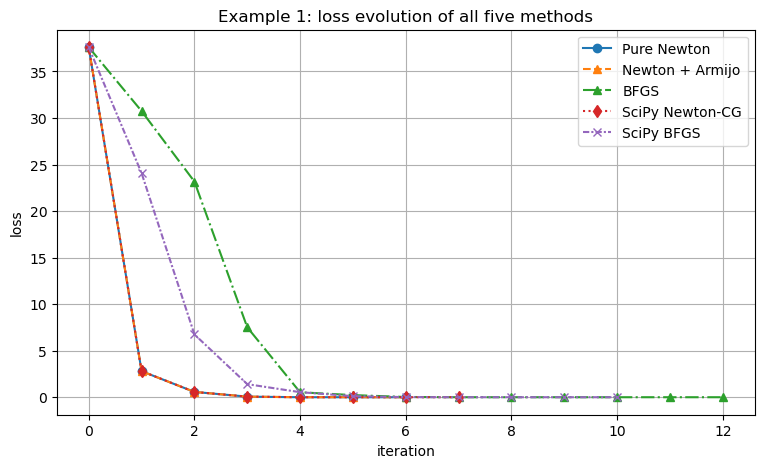

In [41]:
# Create a new figure.
plt.figure(figsize=(9, 5))

# Plot the loss history of pure Newton with a dashed line.
plt.plot(losses_newton, marker="o", label="Pure Newton")

# Plot the loss history of Newton with Armijo with a solid line.
plt.plot(losses_newton_armijo, marker="^", linestyle="--", label="Newton + Armijo")

# Plot the loss history of BFGS with a dash-dot line.
plt.plot(losses_bfgs, marker="^", linestyle="-.", label="BFGS")

# Plot the loss history of SciPy Newton-CG with a dotted line.
plt.plot(losses_newton_cg, marker="d", linestyle=":", label="SciPy Newton-CG")

# Plot the loss history of SciPy BFGS with a custom dashed line.
plt.plot(losses_scipy_bfgs, marker="x", linestyle=(0, (3, 1, 1, 1)), label="SciPy BFGS")

# Label the horizontal axis.
plt.xlabel("iteration")

# Label the vertical axis.
plt.ylabel("loss")

# Add a title.
plt.title("Example 1: loss evolution of all five methods")

# Add a legend.
plt.legend()

# Add a grid.
plt.grid(True)

# Show the plot.
plt.show()

### Final comparison table

The table below summarizes the performance of all methods in Example 1.


In [42]:
# Create a dictionary with the results.
results = {
    "Method": [
        "Pure Newton",
        "Newton + Armijo",
        "BFGS",
        "SciPy Newton-CG",
        "SciPy BFGS"
    ],
    "Iterations": [
        it_newton,
        it_newton_armijo,
        it_bfgs,
        result_newton_cg.nit,
        result_bfgs.nit
    ],
    "Final loss": [
        losses_newton[-1],
        losses_newton_armijo[-1],
        losses_bfgs[-1],
        result_newton_cg.fun,
        result_bfgs.fun
    ],
    "Final solution": [
        x_newton,
        x_newton_armijo,
        x_bfgs,
        result_newton_cg.x,
        result_bfgs.x
    ]
}

# Convert the dictionary into a DataFrame.
df_results = pd.DataFrame(results)

# Display the summary table.
df_results

,Method,Iterations,Final loss,Final solution
0,Pure Newton,7,2.218671e-29,"[1.0000000000000067, -2.0]"
1,Newton + Armijo,7,2.218671e-29,"[1.0000000000000067, -2.0]"
2,BFGS,13,6.901217e-21,"[0.999999999890248, -2.000000000029639]"
3,SciPy Newton-CG,7,2.218671e-29,"[1.0000000000000067, -2.0]"
4,SciPy BFGS,10,5.262639e-13,"[0.9999993984696369, -1.9999994123397649]"


## Example 2

We now test the very same three implemented methods on a larger problem.

We consider the quadratic objective
\begin{equation}
F(x)=\frac{1}{2}x^T A x - b^T x,
\end{equation}
where
\begin{equation}
A \in \mathbb{R}^{n\times n}
\end{equation}
is symmetric positive definite.

Its gradient is
\begin{equation}
\nabla F(x)=Ax-b,
\end{equation}
and its Hessian is
\begin{equation}
H_F(x)=A.
\end{equation}

The exact solution is obtained from
\begin{equation}
Ax=b.
\end{equation}


In [43]:
# Fix the random seed for reproducibility.
np.random.seed(0)

# Define the dimension of the large problem.
n_large = 80

# Generate a random matrix.
M = np.random.randn(n_large, n_large)

# Build a symmetric positive definite matrix.
A_large = M.T @ M + 0.5 * np.eye(n_large)

# Generate a random right-hand side.
b_large = np.random.randn(n_large)

# Define the exact solution by solving the linear system.
x_star_large = np.linalg.solve(A_large, b_large)

# Define the objective function for Example 2.
def f_example_2(x):
    # Return the quadratic objective value.
    return 0.5 * x @ A_large @ x - b_large @ x

# Define the gradient of the objective function for Example 2.
def grad_f_example_2(x):
    # Return the gradient vector.
    return A_large @ x - b_large

# Define the Hessian of the objective function for Example 2.
def hess_f_example_2(x):
    # Return the constant Hessian matrix.
    return A_large

### Run the methods

We now run the three implemented methods on the larger problem and measure:
- the final solution,
- the number of iterations,
- the final loss.

In [44]:
# Define the initial point for Example 2.
x0_example_2 = np.zeros(n_large)

# Run pure Newton on Example 2.
x_newton_large, losses_newton_large, it_newton_large = newton_method(
    f_example_2,
    grad_f_example_2,
    hess_f_example_2,
    x0_example_2,
    tol=1e-8,
    max_iter=50
)


# Run Newton with Armijo on Example 2.
x_newton_armijo_large, losses_newton_armijo_large, it_newton_armijo_large = newton_armijo(
    f_example_2,
    grad_f_example_2,
    hess_f_example_2,
    x0_example_2,
    tol=1e-8,
    max_iter=50
)


# Run BFGS on Example 2.
x_bfgs_large, losses_bfgs_large, it_bfgs_large = bfgs_method(
    f_example_2,
    grad_f_example_2,
    x0_example_2,
    tol=1e-8,
    max_iter=100
)


# Print the results for pure Newton.
print("Example 2: Pure Newton")
print("iterations      =", it_newton_large)
print("final loss      =", losses_newton_large[-1])
print()

# Print the results for Newton with Armijo.
print("Example 2: Newton + Armijo")
print("iterations      =", it_newton_armijo_large)
print("final loss      =", losses_newton_armijo_large[-1])
print()

# Print the results for BFGS.
print("Example 2: BFGS")
print("iterations      =", it_bfgs_large)
print("final loss      =", losses_bfgs_large[-1])
print()

# Print the error with respect to the exact solution for pure Newton.
print("Error Pure Newton       =", np.linalg.norm(x_newton_large - x_star_large))

# Print the error with respect to the exact solution for Newton with Armijo.
print("Error Newton + Armijo   =", np.linalg.norm(x_newton_armijo_large - x_star_large))

# Print the error with respect to the exact solution for BFGS.
print("Error BFGS              =", np.linalg.norm(x_bfgs_large - x_star_large))

Example 2: Pure Newton
iterations      = 2
final loss      = -8.06377490795667

Example 2: Newton + Armijo
iterations      = 2
final loss      = -8.06377490795667

Example 2: BFGS
iterations      = 94
final loss      = -8.063774907956665

Error Pure Newton       = 0.0
Error Newton + Armijo   = 0.0
Error BFGS              = 7.9701763134221e-10


### Combined Plot

We compare the three implemented methods in a single plot for the large problem.


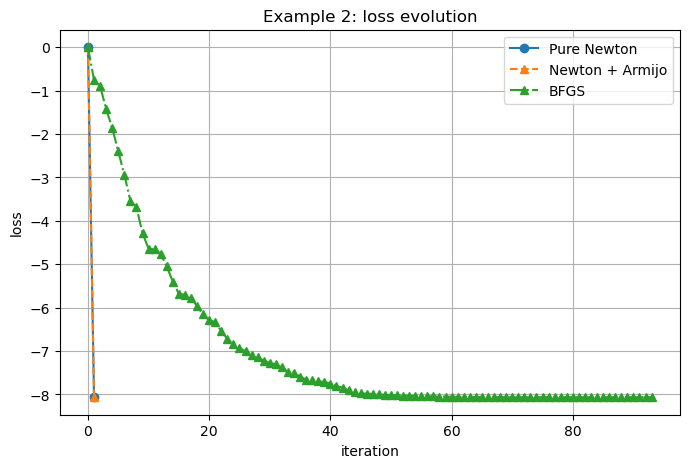

In [45]:
# Create a new figure.
plt.figure(figsize=(8, 5))

# Plot the loss history of pure Newton.
plt.plot(losses_newton_large, marker="o", label="Pure Newton")

# Plot the loss history of Newton with Armijo.
plt.plot(losses_newton_armijo_large, marker="^", linestyle="--", label="Newton + Armijo")

# Plot the loss history of BFGS.
plt.plot(losses_bfgs_large, marker="^", linestyle="-.", label="BFGS")

# Label the horizontal axis.
plt.xlabel("iteration")

# Label the vertical axis.
plt.ylabel("loss")

# Add a title.
plt.title("Example 2: loss evolution")

# Add a legend.
plt.legend()

# Add a grid.
plt.grid(True)

# Show the plot.
plt.show()

### Final comparison table

The table below summarizes the three implemented methods in Example 2.


In [46]:
# Create a dictionary with the results for Example 2.
results_large = {
    "Method": [
        "Pure Newton",
        "Newton + Armijo",
        "BFGS"
    ],
    "Iterations": [
        it_newton_large,
        it_newton_armijo_large,
        it_bfgs_large
    ],
    "Final loss": [
        losses_newton_large[-1],
        losses_newton_armijo_large[-1],
        losses_bfgs_large[-1]
    ],
    "Solution error": [
        np.linalg.norm(x_newton_large - x_star_large),
        np.linalg.norm(x_newton_armijo_large - x_star_large),
        np.linalg.norm(x_bfgs_large - x_star_large)
    ]
}

# Convert the dictionary into a DataFrame.
df_results_large = pd.DataFrame(results_large)

# Display the summary table.
df_results_large

,Method,Iterations,Final loss,Solution error
0,Pure Newton,2,-8.063775,0.000000e+00
1,Newton + Armijo,2,-8.063775,0.000000e+00
2,BFGS,94,-8.063775,7.970176e-10


## Example 3

We consider the following function:
\begin{equation}
f(x)=x^4-x^2.
\end{equation}

The gradient and Hessian are:
\begin{equation}
f'(x)=4x^3-2x, \qquad f''(x)=12x^2-2.
\end{equation}

Stationary points satisfy $f'(x)=0$, giving:
\begin{equation}
x=0, \quad x=\pm \frac{1}{\sqrt{2}}.
\end{equation}

- $x=0$ is a local maximum,
- $x=\pm \frac{1}{\sqrt{2}}$ are local minima.

Starting near $x=0$, Newton's method may fail because the Hessian is negative or close to zero, leading to non-descent directions or unstable steps.


In [47]:
def f3(x):
    return x[0]**4 - x[0]**2

def grad3(x):
    return np.array([4*x[0]**3 - 2*x[0]])

def hess3(x):
    return np.array([[12*x[0]**2 - 2]])

### Run the methods

We now run the three implemented methods on the larger problem and measure:
- the final solution,
- the number of iterations,
- the final loss.

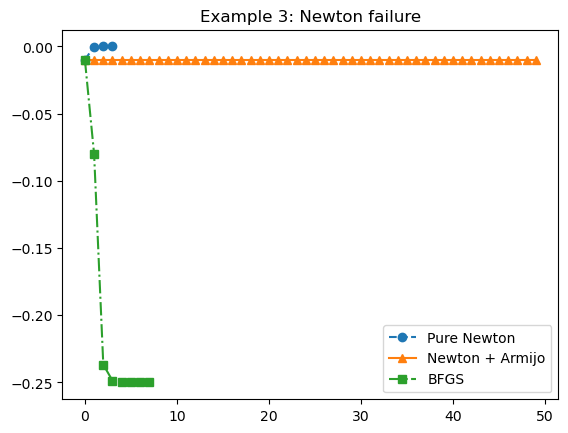

Solutions:
Newton: [-1.17155245e-19]
Armijo: [0.1]
BFGS: [0.70710678]


In [48]:
# Starting point
x0 = np.array([0.1])

x_newton3, losses_newton3, _ = newton_method(f3, grad3, hess3, x0)
x_armijo3, losses_armijo3, _ = newton_armijo(f3, grad3, hess3, x0)
x_bfgs3, losses_bfgs3, _ = bfgs_method(f3, grad3, x0)

plt.figure()
plt.plot(losses_newton3, marker="o", linestyle="--", label="Pure Newton")
plt.plot(losses_armijo3, marker="^", linestyle="-", label="Newton + Armijo")
plt.plot(losses_bfgs3, marker="s", linestyle="-.", label="BFGS")
plt.legend()
plt.title("Example 3: Newton failure")
plt.show()

print("Solutions:")
print("Newton:", x_newton3)
print("Armijo:", x_armijo3)
print("BFGS:", x_bfgs3)


### Interpretation of Example 3:

We consider the non-convex function
\begin{equation}
f(x) = x^4 - x^2.
\end{equation}

---

#### 1. Stationary Points and Their Nature

The first derivative is
\begin{equation}
f'(x) = 4x^3 - 2x = 2x(2x^2 - 1),
\end{equation}
so the stationary points satisfy
\begin{equation}
f'(x) = 0 \quad \Longrightarrow \quad x = 0, \quad x = \pm \frac{1}{\sqrt{2}}.
\end{equation}

The second derivative is
\begin{equation}
f''(x) = 12x^2 - 2.
\end{equation}

Evaluating:
- At $x = 0$:
\begin{equation}
f''(0) = -2 < 0,
\end{equation}
so $x = 0$ is a **local maximum**.

- At $x = \pm \frac{1}{\sqrt{2}}$:
\begin{equation}
f''\!\left(\pm \frac{1}{\sqrt{2}}\right) = 4 > 0,
\end{equation}
so these points are **local (and global) minima**, with
\begin{equation}
f\!\left(\pm \frac{1}{\sqrt{2}}\right) = -\frac{1}{4}.
\end{equation}

---

#### 2. Behavior of Newton's Method

Newton's method computes the update
\begin{equation}
x_{k+1} = x_k - \frac{f'(x_k)}{f''(x_k)}.
\end{equation}

This method is derived from solving
\begin{equation}
f'(x) = 0,
\end{equation}
so it is fundamentally a **root-finding method**, not a method that guarantees minimization.

---

#### 3. Why Newton Fails in This Example

Suppose we start near $x = 0$, for instance $x_0 = 0.1$.

At this point:
\begin{equation}
f''(x_0) = 12x_0^2 - 2 < 0,
\end{equation}
so the curvature is **negative**.

The Newton direction is
\begin{equation}
p_k = -\frac{f'(x_k)}{f''(x_k)}.
\end{equation}

Because $f''(x_k) < 0$, the denominator changes the sign of the step, and the direction may:
- point **toward the maximum**, or
- fail to be a descent direction.

As a result, Newton's method converges to
\begin{equation}
x = 0,
\end{equation}
which is a **local maximum**, not a minimum.

---

#### 4. Behavior of Newton with Armijo Line Search

The Armijo condition requires a **descent direction**:
\begin{equation}
f(x_k + \alpha p_k) \le f(x_k) + c \alpha f'(x_k)p_k.
\end{equation}

If the Newton direction is not a descent direction, i.e.,
\begin{equation}
f'(x_k)p_k \ge 0,
\end{equation}
then the condition cannot be satisfied.

In this case:
- the step is repeatedly rejected,
- the algorithm **does not move**,
- the method stagnates at the initial point.

---

#### 5. Behavior of BFGS

BFGS constructs an approximation $\tilde{H}_k$ of the inverse Hessian that is **positive definite**.

The search direction is
\begin{equation}
p_k = -\tilde{H}_k \nabla f(x_k),
\end{equation}
which guarantees
\begin{equation}
\nabla f(x_k)^T p_k < 0,
\end{equation}
so it is always a **descent direction**.

Therefore:
- the method avoids moving toward maxima,
- it follows a descent path,
- it converges to a true minimum.

In this example, BFGS converges to
\begin{equation}
x \approx -\frac{1}{\sqrt{2}},
\end{equation}
with
\begin{equation}
f(x) \approx -0.25.
\end{equation}

---

#### 6. Key Takeaways

- Newton's method solves $f'(x)=0$, not $\min f(x)$.
- It may converge to maxima or saddle points.
- If the Hessian is not positive definite, the Newton direction may not be a descent direction.
- Line search methods (e.g., Armijo) may prevent divergence but can lead to stagnation.
- Quasi-Newton methods (e.g., BFGS) enforce descent directions and are more robust in practice.

In [49]:
SELECT DIFFERENT STARTING POINTS FOR THIS PROBLEM

SyntaxError: invalid syntax (3521691711.py, line 1)